# 01 · Traditional EDA — Reality Check
## Delhivery ETA Optimisation · GraphSAGE Network Intelligence

**Objective:** Expose *why* OSRM's clean-traffic estimates systematically underestimate real delivery times. Every finding here motivates a design decision in the downstream graph pipeline.

| Phase | Notebook |
|-------|----------|
| **1 — EDA (this notebook)** | Understand raw data, clean, visualise OSRM vs actual skew |
| 2 — Graph Construction | Convert cleaned trips into a directed weighted graph |
| 3 — GraphSAGE Training | Learn hub embeddings; train ETA regressor |

---


In [2]:
# ============================================================
# CELL 1 — IMPORTS & GLOBAL CONFIG
# ============================================================
# All third-party dependencies are declared here so that any
# collaborator can reproduce the environment with a single
# `pip install` command.

import warnings
warnings.filterwarnings("ignore")

import os
import glob
from pathlib import Path
from typing import List, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats

# ── Plotting aesthetics ──────────────────────────────────────
sns.set_theme(style="darkgrid", palette="muted", font_scale=1.15)
plt.rcParams.update({
    "figure.dpi": 120,
    "figure.facecolor": "white",
    "axes.facecolor": "#F8F9FA",
    "axes.titleweight": "bold",
})
ACCENT = "#E74C3C"   # highlight colour for OSRM / actual comparisons
OK     = "#2ECC71"   # clean-data colour

# ── Reproducibility ─────────────────────────────────────────
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

print("✅ Imports OK")
print(f"   pandas  {pd.__version__} | numpy {np.__version__}")


✅ Imports OK
   pandas  3.0.3 | numpy 2.4.6


---
## 1 · Data Ingestion

We load all three raw trip-log shards (`data_part_1/2/3.csv`) and concatenate them. The `data` column encodes the train/test split assigned by Delhivery upstream — we **preserve** that split throughout all analysis to avoid leakage.


In [4]:
# ============================================================
# CELL 2 — DATA INGESTION
# ============================================================

# ── Locate raw CSV shards ────────────────────────────────────
# Adjust DATA_DIR if your repo layout differs from the standard
# /data/raw/ structure.
DATA_DIR = Path("../data")          # default repo layout
ALT_DIR  = Path(".")                # fallback: same directory as notebook

def find_shards(base: Path) -> List[Path]:
    """Return sorted list of data_part_*.csv files under *base*."""
    pattern = str(base / "data_part_*.csv")
    found   = sorted(glob.glob(pattern))
    return [Path(p) for p in found]

shards = find_shards(DATA_DIR)
if not shards:
    shards = find_shards(ALT_DIR)   # try sibling folder
if not shards:
    raise FileNotFoundError(
        "Could not locate data_part_*.csv. "
        "Place the raw CSVs in ../data/ relative to this notebook."
    )

print(f"📂 Found {len(shards)} shard(s):")
for s in shards:
    print(f"   {s}  ({s.stat().st_size / 1e6:.1f} MB)")

# ── Dtype map — enforced at load time for memory efficiency ──
DTYPE_MAP = {
    "data":                          "category",
    "route_schedule_uuid":           "string",
    "route_type":                    "category",
    "trip_uuid":                     "string",
    "source_center":                 "string",
    "source_name":                   "string",
    "destination_center":            "string",
    "destination_name":              "string",
    "start_scan_to_end_scan":        "float32",
    "is_cutoff":                     "bool",
    "cutoff_factor":                 "int16",
    "actual_distance_to_destination":"float32",
    "actual_time":                   "float32",
    "osrm_time":                     "float32",
    "osrm_distance":                 "float32",
    "factor":                        "float32",
    "segment_actual_time":           "float32",
    "segment_osrm_time":             "float32",
    "segment_osrm_distance":         "float32",
    "segment_factor":                "float32",
}

DATE_COLS = [
    "trip_creation_time",
    "od_start_time",
    "od_end_time",
    "cutoff_timestamp",
]

def load_shard(path: Path) -> pd.DataFrame:
    """
    Load a single CSV shard with enforced dtypes and parsed timestamps.

    Parameters
    ----------
    path : Path
        Absolute path to the CSV file.

    Returns
    -------
    pd.DataFrame
        Typed DataFrame ready for concatenation.
    """
    return pd.read_csv(
        path,
        dtype=DTYPE_MAP,
        parse_dates=DATE_COLS,
        low_memory=False,
    )

# ── Load & concatenate ───────────────────────────────────────
raw_parts = [load_shard(s) for s in shards]
df_raw    = pd.concat(raw_parts, ignore_index=True)

print(f"\n📊 Raw dataset  →  {df_raw.shape[0]:,} rows × {df_raw.shape[1]} columns")
print(f"   Memory usage : {df_raw.memory_usage(deep=True).sum() / 1e6:.1f} MB")
print(f"\nColumn list:\n{list(df_raw.columns)}")


📂 Found 3 shard(s):
   ../data/data_part_1.csv  (18.4 MB)
   ../data/data_part_2.csv  (18.4 MB)
   ../data/data_part_3.csv  (18.4 MB)

📊 Raw dataset  →  144,867 rows × 24 columns
   Memory usage : 43.8 MB

Column list:
['data', 'trip_creation_time', 'route_schedule_uuid', 'route_type', 'trip_uuid', 'source_center', 'source_name', 'destination_center', 'destination_name', 'od_start_time', 'od_end_time', 'start_scan_to_end_scan', 'is_cutoff', 'cutoff_factor', 'cutoff_timestamp', 'actual_distance_to_destination', 'actual_time', 'osrm_time', 'osrm_distance', 'factor', 'segment_actual_time', 'segment_osrm_time', 'segment_osrm_distance', 'segment_factor']


---
## 2 · Missing Data Audit

Nulls in hub-ID columns (`source_center`, `destination_center`) would create phantom nodes in our graph — we must remove those rows. Nulls in human-readable name columns (`source_name`, `destination_name`) are tolerated since we use the machine IDs for graph construction.


=== Null Audit (all columns) ===
                  null_count  null_pct_%
source_name              293       0.202
destination_name         261       0.180


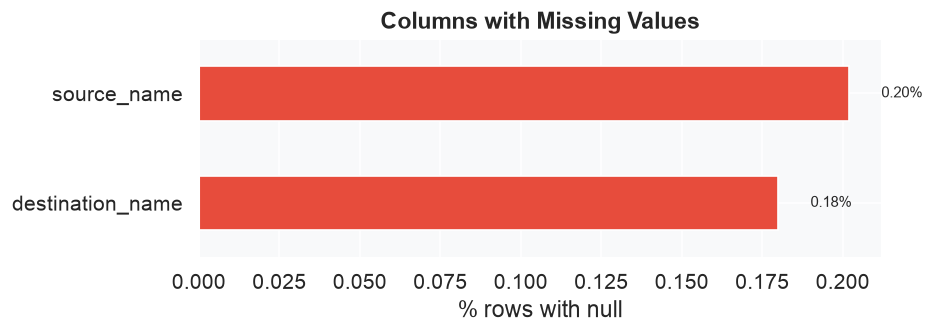

   → plot saved to ../data/null_audit.png

=== Critical Graph Columns ===
source_center         0
destination_center    0
actual_time           0
osrm_time             0
dtype: int64

Rows removed for critical nulls: 0
Rows remaining               : 144,867


In [5]:
# ============================================================
# CELL 3 — MISSING DATA AUDIT
# ============================================================

# ── Compute null summary ─────────────────────────────────────
null_counts = df_raw.isnull().sum()
null_pct    = (null_counts / len(df_raw) * 100).round(3)
null_df = (
    pd.DataFrame({"null_count": null_counts, "null_pct_%": null_pct})
    .sort_values("null_count", ascending=False)
)
print("=== Null Audit (all columns) ===")
print(null_df[null_df.null_count > 0].to_string())

# ── Visualise ────────────────────────────────────────────────
non_zero = null_df[null_df.null_count > 0]
if not non_zero.empty:
    fig, ax = plt.subplots(figsize=(8, max(3, len(non_zero) * 0.5)))
    non_zero["null_pct_%"].sort_values().plot(
        kind="barh", ax=ax, color=ACCENT, edgecolor="white"
    )
    ax.set_xlabel("% rows with null")
    ax.set_title("Columns with Missing Values")
    for i, v in enumerate(non_zero["null_pct_%"].sort_values()):
        ax.text(v + 0.01, i, f"{v:.2f}%", va="center", fontsize=9)
    plt.tight_layout()
    plt.savefig("../data/null_audit.png", bbox_inches="tight")
    plt.show()
    print("   → plot saved to ../data/null_audit.png")
else:
    print("✅ No nulls found in critical ID columns.")

# ── CRITICAL columns where nulls break the graph ─────────────
CRITICAL_COLS = ["source_center", "destination_center", "actual_time", "osrm_time"]
critical_nulls = df_raw[CRITICAL_COLS].isnull().sum()
print("\n=== Critical Graph Columns ===")
print(critical_nulls)

n_before = len(df_raw)
df_no_crit_nulls = df_raw.dropna(subset=CRITICAL_COLS)
print(f"\nRows removed for critical nulls: {n_before - len(df_no_crit_nulls):,}")
print(f"Rows remaining               : {len(df_no_crit_nulls):,}")


---
## 3 · Initial Distribution Check — OSRM vs Actual Time

Before cleaning, we visualise the raw `actual_time` vs `osrm_time` distributions and the `factor` (= actual / OSRM) to quantify the systematic underestimation.


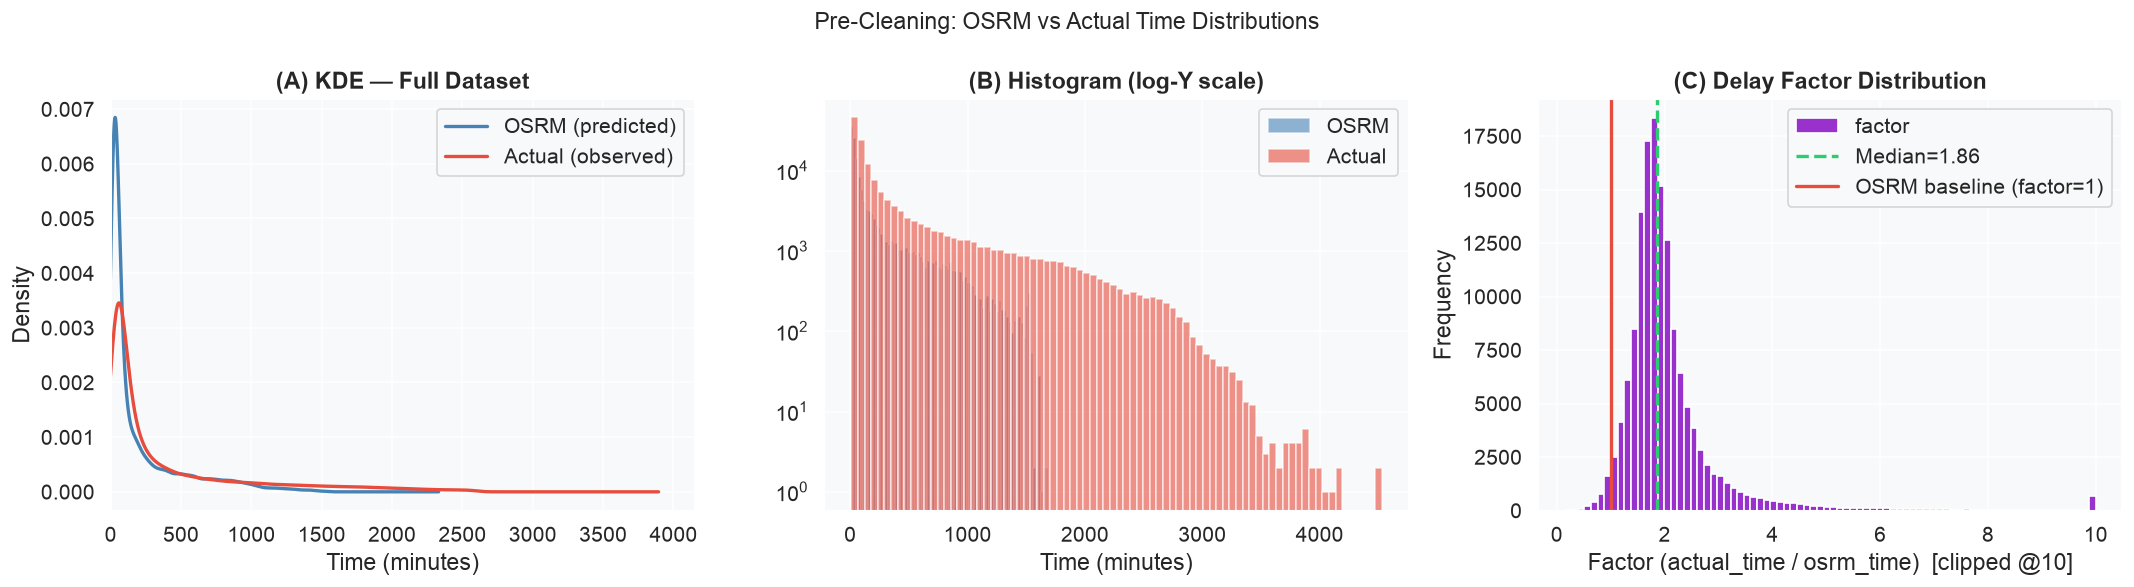

=== Pre-Cleaning Summary Statistics ===
         actual_time      osrm_time         factor
count  144867.000000  144867.000000  144867.000000
mean      416.927521     213.868286       2.120107
std       598.103638     308.011078       1.715421
min         9.000000       6.000000       0.144000
1%         14.000000       8.000000       0.877551
5%         22.000000      12.000000       1.181818
25%        51.000000      27.000000       1.604264
50%       132.000000      64.000000       1.857143
75%       513.000000     257.000000       2.213483
95%      1823.000000     925.000000       3.612706
99%      2599.000000    1355.000000       6.958900
max      4532.000000    1686.000000      77.387100

📌 OSRM Baseline MAE      : 203.42 min
📌 Mean delay factor      : 2.120×  (OSRM underestimates by 112.0%)
📌 Median delay factor    : 1.857×


In [6]:
# ============================================================
# CELL 4 — PRE-CLEANING DISTRIBUTION CHECK
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Pre-Cleaning: OSRM vs Actual Time Distributions", fontsize=14)

# ── (A) Raw KDE overlay ──────────────────────────────────────
ax = axes[0]
# Cap at 99th percentile for visual clarity (does NOT alter data)
cap = df_no_crit_nulls["actual_time"].quantile(0.99)
data_capped = df_no_crit_nulls[df_no_crit_nulls["actual_time"] <= cap]

data_capped["osrm_time"].plot.kde(ax=ax, color="steelblue",  linewidth=2, label="OSRM (predicted)")
data_capped["actual_time"].plot.kde(ax=ax, color=ACCENT,     linewidth=2, label="Actual (observed)")
ax.set_xlabel("Time (minutes)")
ax.set_title("(A) KDE — Full Dataset")
ax.legend()
ax.set_xlim(left=0)

# ── (B) Log-scale histogram ──────────────────────────────────
ax = axes[1]
ax.hist(df_no_crit_nulls["osrm_time"],   bins=80, alpha=0.6, color="steelblue", label="OSRM")
ax.hist(df_no_crit_nulls["actual_time"], bins=80, alpha=0.6, color=ACCENT,      label="Actual")
ax.set_yscale("log")
ax.set_xlabel("Time (minutes)")
ax.set_title("(B) Histogram (log-Y scale)")
ax.legend()

# ── (C) Factor distribution ──────────────────────────────────
ax = axes[2]
factor_clean = df_no_crit_nulls["factor"]
factor_clean.clip(0, 10).plot.hist(bins=80, ax=ax, color="darkorchid", edgecolor="white")
ax.axvline(factor_clean.median(), color=OK,     linewidth=2, linestyle="--", label=f"Median={factor_clean.median():.2f}")
ax.axvline(1.0,                   color=ACCENT, linewidth=2, linestyle="-",  label="OSRM baseline (factor=1)")
ax.set_xlabel("Factor (actual_time / osrm_time)  [clipped @10]")
ax.set_title("(C) Delay Factor Distribution")
ax.legend()

plt.tight_layout()
plt.savefig("../data/pre_clean_distributions.png", bbox_inches="tight")
plt.show()

# ── Key statistics ───────────────────────────────────────────
print("=== Pre-Cleaning Summary Statistics ===")
summary = df_no_crit_nulls[["actual_time","osrm_time","factor"]].describe(
    percentiles=[0.01,0.05,0.25,0.5,0.75,0.95,0.99]
)
print(summary.to_string())

# ── Mean absolute underestimation ────────────────────────────
mae_baseline = (df_no_crit_nulls["actual_time"] - df_no_crit_nulls["osrm_time"]).abs().mean()
mean_factor  = df_no_crit_nulls["factor"].mean()
med_factor   = df_no_crit_nulls["factor"].median()
print(f"\n📌 OSRM Baseline MAE      : {mae_baseline:.2f} min")
print(f"📌 Mean delay factor      : {mean_factor:.3f}×  (OSRM underestimates by {(mean_factor-1)*100:.1f}%)")
print(f"📌 Median delay factor    : {med_factor:.3f}×")


---
## 4 · Outlier Detection & Cleaning

**Why this matters for our graph:** Edge weights are medians of the delay-factor per corridor. A single physically-impossible trip (e.g., `factor = 493`) can bias an entire edge, causing the GraphSAGE model to learn from corrupted signal.

We apply **domain-driven** filters (not arbitrary statistical percentiles), derived from logistics operations knowledge:

| Filter | Rationale |
|--------|-----------|
| `actual_time <= 0` | Trip can't have zero or negative duration |
| `osrm_time <= 0` | OSRM produced an invalid route estimate |
| `factor < 0.2` | Arriving 5× faster than OSRM is physically impossible on Indian roads |
| `factor > 10` | A 10× overrun implies GPS error, multi-day parking, or data entry fault |
| `segment_factor < 0` | Negative ratio: scan order mismatch / data pipeline error |
| `actual_distance_to_destination <= 0` | Zero-distance leg is a data artefact |


=== Outlier Removal Summary ===
  Rows before  :    144,867
  Rows dropped :      3,002  (2.07%)
  Rows after   :    141,865

=== Dropped rows per rule (may overlap) ===
  actual_time < 1 min                :       0
  osrm_time < 1 min                  :       0
  factor < 0.2 (too fast)            :       1
  factor > 10 (implausible)          :     650
  segment_factor < 0 (error)         :   2,365
  distance <= 0.1 km                 :       0


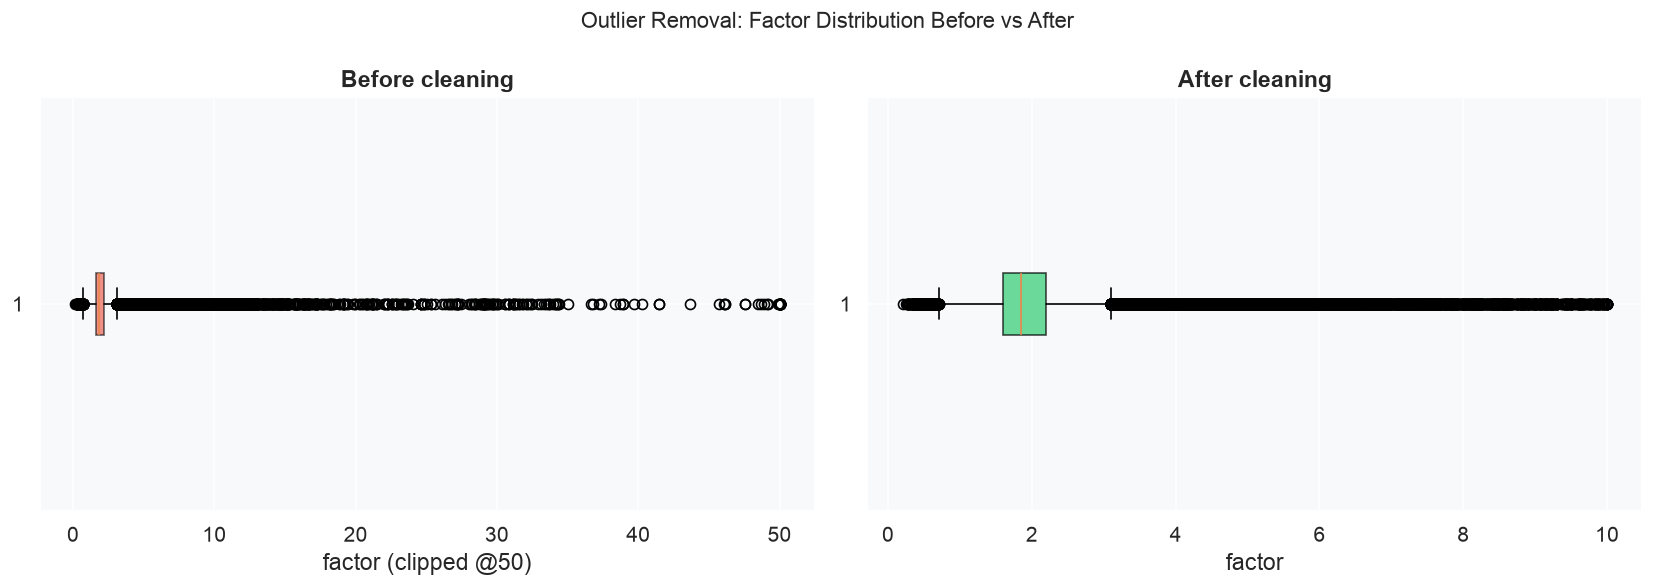

In [7]:
# ============================================================
# CELL 5 — OUTLIER DETECTION & CLEANING
# ============================================================

LOWER_FACTOR  = 0.2   # arriving 5× faster than OSRM — physically impossible
UPPER_FACTOR  = 10.0  # 10× overrun — GPS lost / multi-day hold / data error
MIN_DIST_KM   = 0.1   # minimum plausible segment distance (km)
MIN_TIME_MIN  = 1.0   # minimum plausible trip time (minutes)

def build_outlier_mask(df: pd.DataFrame) -> pd.Series:
    """
    Return a boolean mask (True = KEEP) after applying all domain-driven
    outlier filters.

    Parameters
    ----------
    df : pd.DataFrame
        Raw or partially-cleaned trip DataFrame.

    Returns
    -------
    pd.Series[bool]
        True for rows that pass ALL filters.

    Notes
    -----
    Filters are **AND-chained**: a row is dropped if it fails *any* rule.
    We intentionally avoid purely statistical thresholds (IQR / z-score)
    because the factor distribution is heavily right-skewed; a z-score
    cut would retain many bad records while discarding valid long-haul
    outliers. Domain bounds are safer.
    """
    mask = (
        (df["actual_time"]                    >= MIN_TIME_MIN) &
        (df["osrm_time"]                      >= MIN_TIME_MIN) &
        (df["factor"]                         >= LOWER_FACTOR) &
        (df["factor"]                         <= UPPER_FACTOR) &
        (df["segment_factor"]                 >= 0           ) &  # negative = scan reversal
        (df["actual_distance_to_destination"] >= MIN_DIST_KM )
    )
    return mask

mask        = build_outlier_mask(df_no_crit_nulls)
df_clean    = df_no_crit_nulls[mask].copy()
n_dropped   = len(df_no_crit_nulls) - len(df_clean)
drop_pct    = n_dropped / len(df_no_crit_nulls) * 100

print("=== Outlier Removal Summary ===")
print(f"  Rows before  : {len(df_no_crit_nulls):>10,}")
print(f"  Rows dropped : {n_dropped:>10,}  ({drop_pct:.2f}%)")
print(f"  Rows after   : {len(df_clean):>10,}")

# ── Per-rule breakdown ───────────────────────────────────────
rules = {
    "actual_time < 1 min"        : (df_no_crit_nulls["actual_time"] < MIN_TIME_MIN).sum(),
    "osrm_time < 1 min"          : (df_no_crit_nulls["osrm_time"]   < MIN_TIME_MIN).sum(),
    "factor < 0.2 (too fast)"    : (df_no_crit_nulls["factor"]      < LOWER_FACTOR).sum(),
    "factor > 10 (implausible)"  : (df_no_crit_nulls["factor"]      > UPPER_FACTOR).sum(),
    "segment_factor < 0 (error)" : (df_no_crit_nulls["segment_factor"] < 0).sum(),
    "distance <= 0.1 km"         : (df_no_crit_nulls["actual_distance_to_destination"] < MIN_DIST_KM).sum(),
}
print("\n=== Dropped rows per rule (may overlap) ===")
for rule, cnt in rules.items():
    print(f"  {rule:<35}: {cnt:>7,}")

# ── Visual — boxplot before / after ─────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Outlier Removal: Factor Distribution Before vs After", fontsize=13)

axes[0].boxplot(df_no_crit_nulls["factor"].clip(0, 50), vert=False, patch_artist=True,
                boxprops=dict(facecolor=ACCENT, alpha=0.6))
axes[0].set_xlabel("factor (clipped @50)")
axes[0].set_title("Before cleaning")

axes[1].boxplot(df_clean["factor"], vert=False, patch_artist=True,
                boxprops=dict(facecolor=OK, alpha=0.7))
axes[1].set_xlabel("factor")
axes[1].set_title("After cleaning")

plt.tight_layout()
plt.savefig("../data/outlier_boxplot.png", bbox_inches="tight")
plt.show()


---
## 5 · Post-Cleaning Distribution Check

We re-examine OSRM vs Actual and confirm the underestimation signal survives our cleaning steps — this is the **ground truth** our GraphSAGE model must learn to correct.


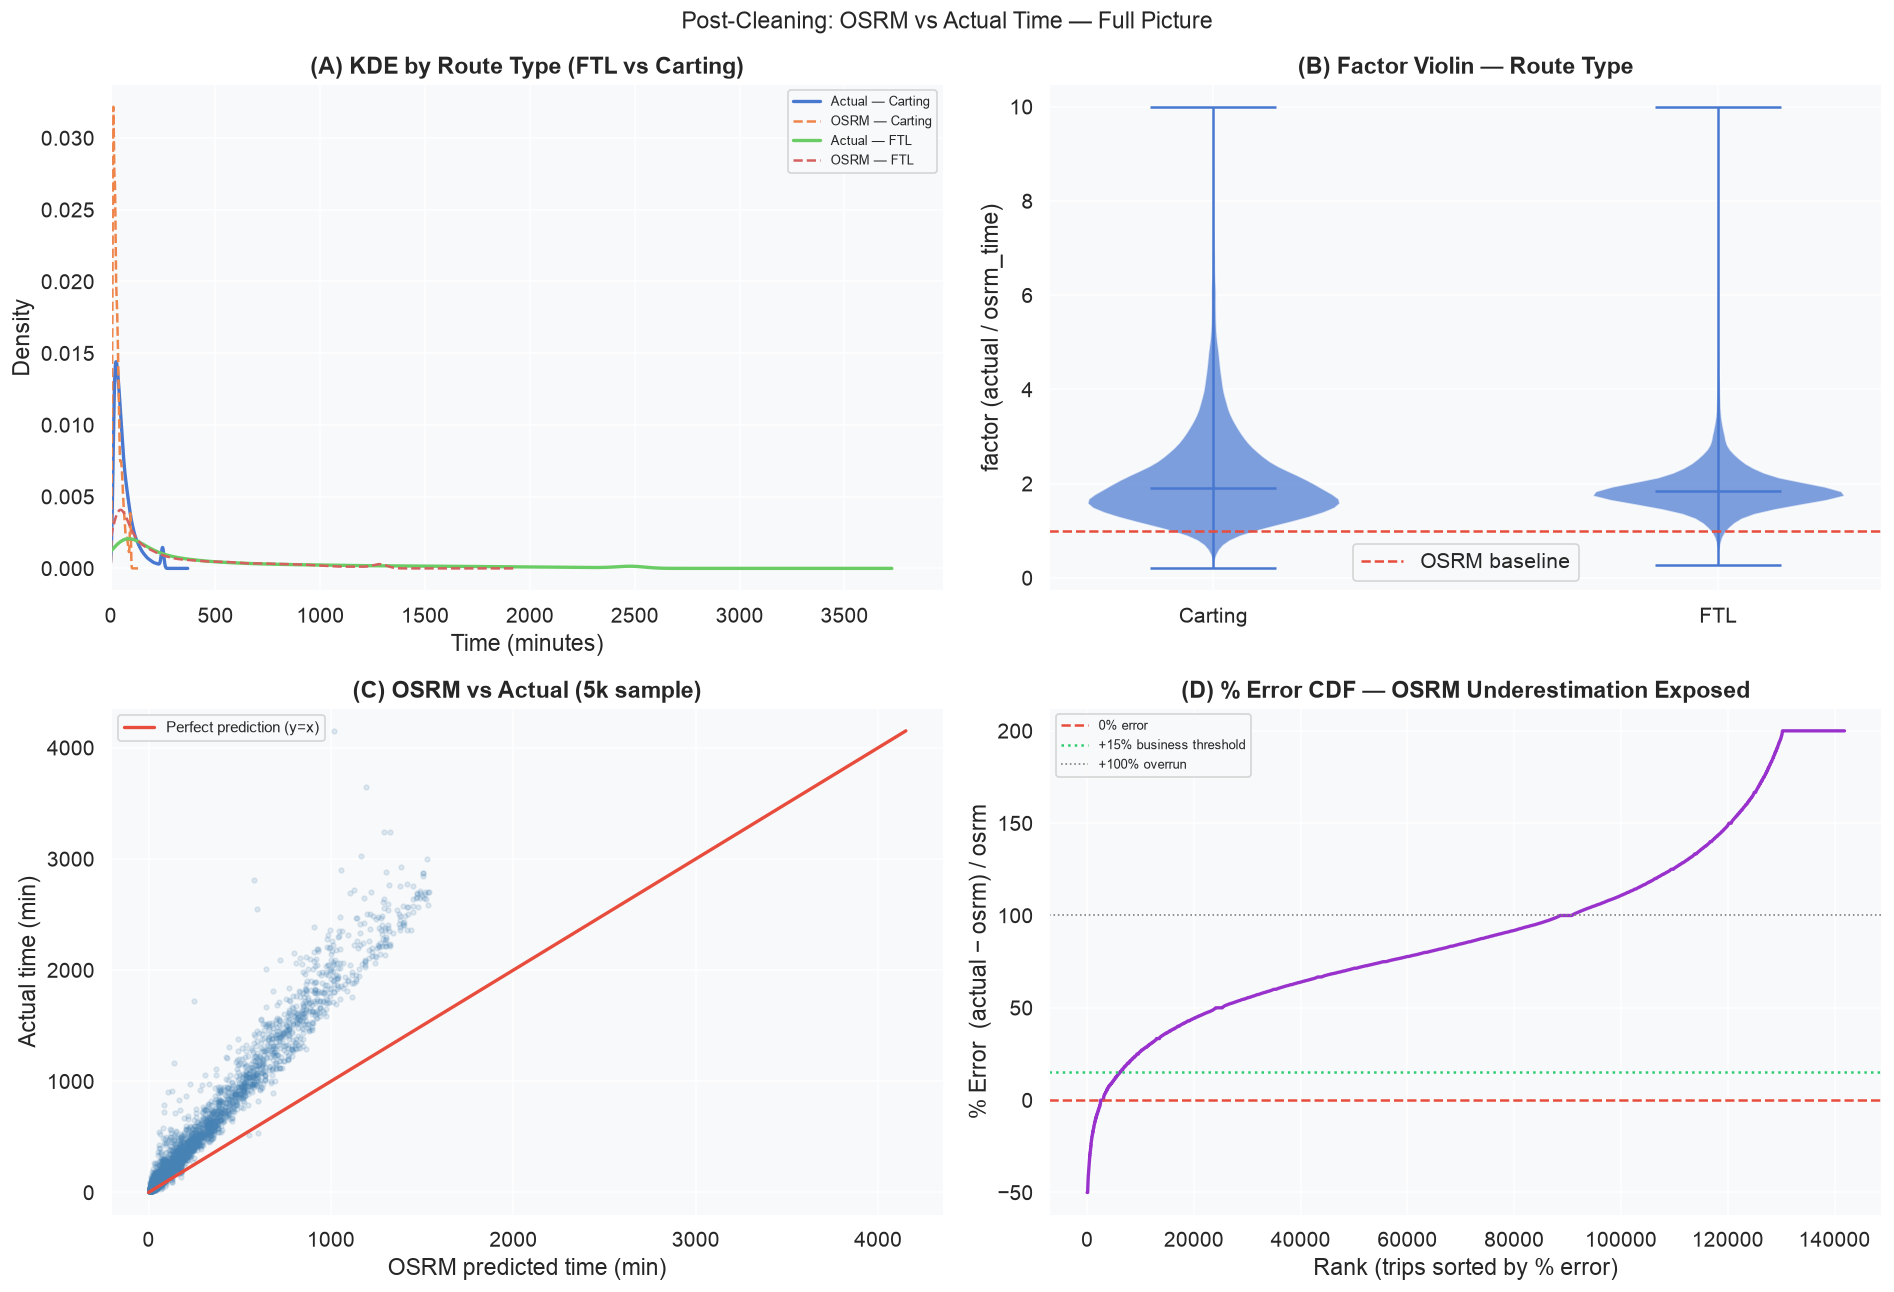

=== Post-Cleaning Summary Statistics ===
         actual_time      osrm_time         factor  segment_factor
count  141865.000000  141865.000000  141865.000000   141865.000000
mean      420.346283     217.050232       2.033911        2.146392
std       601.053284     309.717621       0.865407        2.811929
min         9.000000       6.000000       0.203125        0.000000
5%         22.000000      12.000000       1.181818        0.833333
25%        52.000000      28.000000       1.601073        1.363636
50%       133.000000      66.000000       1.852632        1.692308
75%       519.000000     266.000000       2.200000        2.250000
95%      1831.000000     930.000000       3.471261        4.333333
99%      2603.000000    1359.000000       5.881858        9.756923
max      4532.000000    1686.000000      10.000000      241.000000

📌 OSRM Baseline MAE (clean data)    : 203.66 min
📌 % trips within ±15% of OSRM       : 3.4%  ← GraphSAGE target to beat


In [8]:
# ============================================================
# CELL 6 — POST-CLEANING DISTRIBUTION VISUALISATION
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(16, 11))
fig.suptitle("Post-Cleaning: OSRM vs Actual Time — Full Picture", fontsize=14)

# ── (A) KDE by route type ────────────────────────────────────
ax = axes[0, 0]
for rtype, grp in df_clean.groupby("route_type"):
    grp["actual_time"].clip(upper=grp["actual_time"].quantile(0.98)).plot.kde(
        ax=ax, linewidth=2, label=f"Actual — {rtype}"
    )
    grp["osrm_time"].clip(upper=grp["osrm_time"].quantile(0.98)).plot.kde(
        ax=ax, linewidth=1.5, linestyle="--", label=f"OSRM — {rtype}"
    )
ax.set_xlabel("Time (minutes)")
ax.set_title("(A) KDE by Route Type (FTL vs Carting)")
ax.legend(fontsize=8)
ax.set_xlim(left=0)

# ── (B) Factor violin by route type ─────────────────────────
ax = axes[0, 1]
factor_data = [
    df_clean[df_clean["route_type"] == rt]["factor"].values
    for rt in df_clean["route_type"].cat.categories
]
parts = ax.violinplot(factor_data, vert=True, showmedians=True)
for pc in parts["bodies"]:
    pc.set_alpha(0.7)
ax.set_xticks(range(1, len(df_clean["route_type"].cat.categories) + 1))
ax.set_xticklabels(df_clean["route_type"].cat.categories)
ax.axhline(1.0, color=ACCENT, linestyle="--", linewidth=1.5, label="OSRM baseline")
ax.set_ylabel("factor (actual / osrm_time)")
ax.set_title("(B) Factor Violin — Route Type")
ax.legend()

# ── (C) Scatter: osrm_time vs actual_time (sample 5k) ───────
ax = axes[1, 0]
sample = df_clean.sample(min(5000, len(df_clean)), random_state=RANDOM_SEED)
ax.scatter(sample["osrm_time"], sample["actual_time"],
           alpha=0.15, s=8, c="steelblue")
max_val = max(sample["osrm_time"].max(), sample["actual_time"].max())
ax.plot([0, max_val], [0, max_val], color=ACCENT, linewidth=2,
        label="Perfect prediction (y=x)")
ax.set_xlabel("OSRM predicted time (min)")
ax.set_ylabel("Actual time (min)")
ax.set_title("(C) OSRM vs Actual (5k sample)")
ax.legend(fontsize=9)

# ── (D) Percentage error CDF ─────────────────────────────────
ax = axes[1, 1]
pct_error = ((df_clean["actual_time"] - df_clean["osrm_time"])
             / df_clean["osrm_time"] * 100).clip(-50, 200)
pct_error.sort_values().reset_index(drop=True).plot(
    ax=ax, linewidth=2, color="darkorchid"
)
ax.axhline(0,   color=ACCENT, linewidth=1.5, linestyle="--", label="0% error")
ax.axhline(15,  color=OK,     linewidth=1.5, linestyle=":",  label="+15% business threshold")
ax.axhline(100, color="gray", linewidth=1,   linestyle=":",  label="+100% overrun")
ax.set_xlabel("Rank (trips sorted by % error)")
ax.set_ylabel("% Error  (actual − osrm) / osrm")
ax.set_title("(D) % Error CDF — OSRM Underestimation Exposed")
ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig("../data/post_clean_distributions.png", bbox_inches="tight")
plt.show()

# ── Summary stats post-cleaning ──────────────────────────────
print("=== Post-Cleaning Summary Statistics ===")
print(df_clean[["actual_time","osrm_time","factor","segment_factor"]].describe(
    percentiles=[0.05,0.25,0.5,0.75,0.95,0.99]
).to_string())

mae_clean  = (df_clean["actual_time"] - df_clean["osrm_time"]).abs().mean()
pct_within_15 = (pct_error.abs() <= 15).mean() * 100
print(f"\n📌 OSRM Baseline MAE (clean data)    : {mae_clean:.2f} min")
print(f"📌 % trips within ±15% of OSRM       : {pct_within_15:.1f}%  ← GraphSAGE target to beat")


---
## 6 · Temporal Analysis — Hour-of-Day Congestion Patterns

These patterns feed directly into our **time-stratified edge weights** in the graph. A corridor that is 1.8× at 3 AM may be 3.2× at 9 AM — the graph must encode this.


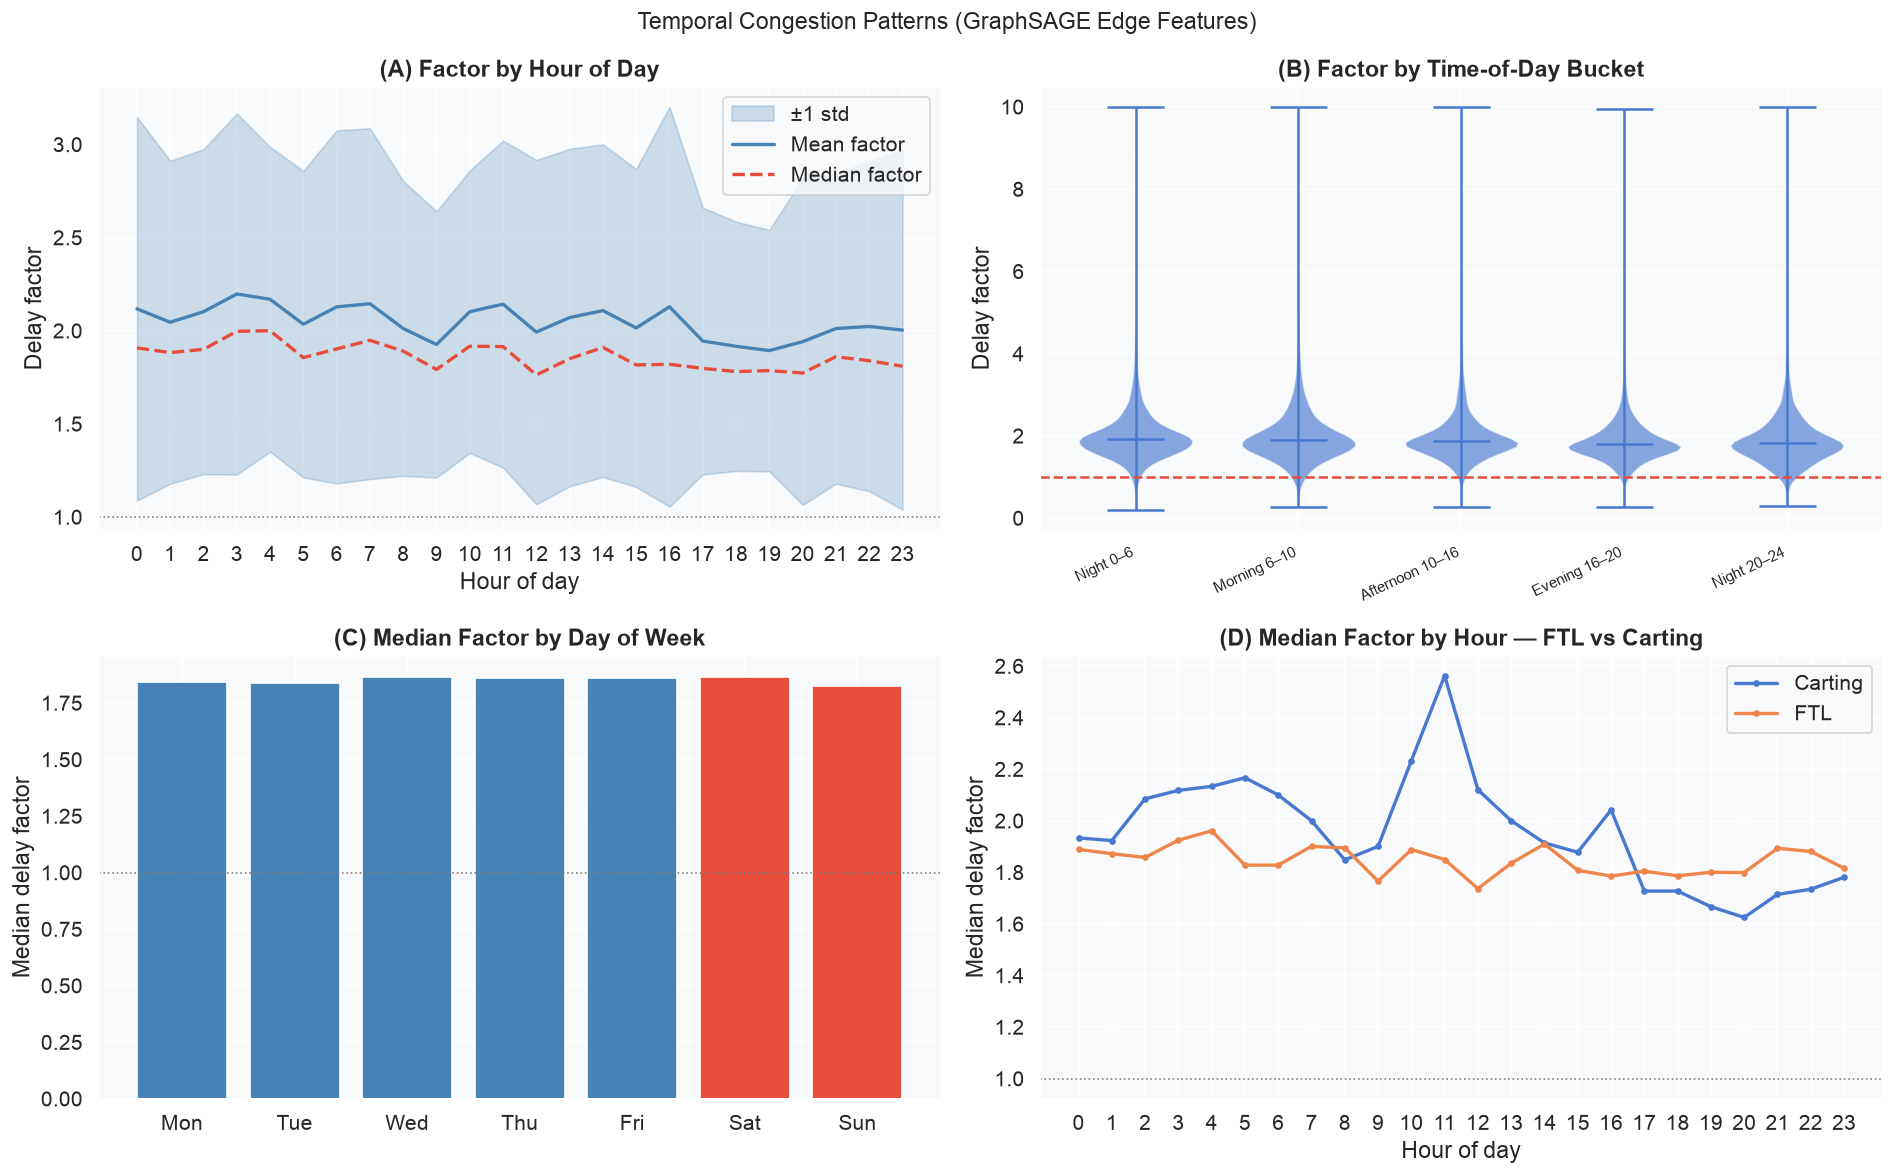

=== Time-of-Day Factor Summary ===
                 count   mean  median    std
time_of_day                                 
Night 0–6        41232  2.105   1.917  0.902
Morning 6–10     12926  2.060   1.889  0.867
Afternoon 10–16  20564  2.071   1.864  0.873
Evening 16–20    27425  1.943   1.789  0.745
Night 20–24      39718  1.995   1.815  0.891


In [9]:
# ============================================================
# CELL 7 — TEMPORAL ANALYSIS
# ============================================================

# ── Extract temporal features ────────────────────────────────
df_clean = df_clean.copy()
df_clean["hour_of_day"]  = df_clean["trip_creation_time"].dt.hour
df_clean["day_of_week"]  = df_clean["trip_creation_time"].dt.dayofweek   # 0=Mon
df_clean["is_weekend"]   = df_clean["day_of_week"].isin([5, 6])

# ── Time-of-day buckets (for edge stratification in graph) ───
TOD_BINS   = [0, 6, 10, 16, 20, 24]
TOD_LABELS = ["Night 0–6", "Morning 6–10", "Afternoon 10–16",
              "Evening 16–20", "Night 20–24"]
df_clean["time_of_day"] = pd.cut(
    df_clean["hour_of_day"], bins=TOD_BINS, labels=TOD_LABELS, right=False
)

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle("Temporal Congestion Patterns (GraphSAGE Edge Features)", fontsize=14)

# ── (A) Mean factor by hour ──────────────────────────────────
ax = axes[0, 0]
hourly = df_clean.groupby("hour_of_day")["factor"].agg(["mean", "median", "std"])
ax.fill_between(hourly.index,
                hourly["mean"] - hourly["std"],
                hourly["mean"] + hourly["std"],
                alpha=0.25, color="steelblue", label="±1 std")
ax.plot(hourly.index, hourly["mean"],   color="steelblue", linewidth=2, label="Mean factor")
ax.plot(hourly.index, hourly["median"], color=ACCENT,      linewidth=2,
        linestyle="--", label="Median factor")
ax.axhline(1.0, color="gray", linestyle=":", linewidth=1)
ax.set_xticks(range(0, 24))
ax.set_xlabel("Hour of day")
ax.set_ylabel("Delay factor")
ax.set_title("(A) Factor by Hour of Day")
ax.legend()

# ── (B) Time-of-day bucket violin ───────────────────────────
ax = axes[0, 1]
tod_groups = [
    df_clean[df_clean["time_of_day"] == lbl]["factor"].dropna().values
    for lbl in TOD_LABELS
]
parts = ax.violinplot(tod_groups, showmedians=True, widths=0.7)
for pc in parts["bodies"]:
    pc.set_alpha(0.65)
ax.set_xticks(range(1, len(TOD_LABELS)+1))
ax.set_xticklabels(TOD_LABELS, rotation=25, ha="right", fontsize=9)
ax.axhline(1.0, color=ACCENT, linestyle="--", linewidth=1.5)
ax.set_ylabel("Delay factor")
ax.set_title("(B) Factor by Time-of-Day Bucket")

# ── (C) Factor by day of week ────────────────────────────────
ax = axes[1, 0]
DOW_LABELS = ["Mon","Tue","Wed","Thu","Fri","Sat","Sun"]
dow = df_clean.groupby("day_of_week")["factor"].median()
ax.bar(DOW_LABELS, dow.values, color=["#E74C3C" if i >= 5 else "steelblue" for i in range(7)])
ax.axhline(1.0, color="gray", linestyle=":", linewidth=1)
ax.set_ylabel("Median delay factor")
ax.set_title("(C) Median Factor by Day of Week")

# ── (D) FTL vs Carting factor by hour ───────────────────────
ax = axes[1, 1]
for rtype, grp in df_clean.groupby("route_type"):
    h = grp.groupby("hour_of_day")["factor"].median()
    ax.plot(h.index, h.values, linewidth=2, marker="o", markersize=3, label=rtype)
ax.axhline(1.0, color="gray", linestyle=":", linewidth=1)
ax.set_xticks(range(0, 24))
ax.set_xlabel("Hour of day")
ax.set_ylabel("Median delay factor")
ax.set_title("(D) Median Factor by Hour — FTL vs Carting")
ax.legend()

plt.tight_layout()
plt.savefig("../data/temporal_congestion.png", bbox_inches="tight")
plt.show()

print("=== Time-of-Day Factor Summary ===")
tod_summary = (
    df_clean.groupby("time_of_day", observed=True)["factor"]
    .agg(count="count", mean="mean", median="median", std="std")
    .round(3)
)
print(tod_summary.to_string())


---
## 7 · Graph Structure Preview — Nodes & Edges

A first look at the logistics network we are about to build. This section **does not** build the full PyTorch Geometric graph (that's `02_data_pipeline.ipynb`) but establishes the key statistics that will drive our GraphSAGE architecture decisions.


🔵 Unique hub nodes : 1,655
🟢 Unique directed edges (src→dst×route_type): 2,790
   of which FTL    : 1,725
   of which Carting: 1,065

=== Top 10 Corridors by Trip Volume ===
source_center destination_center route_type  trips  median_factor  median_dist_km
 IND562132AAA       IND560300AAA    Carting    151       1.600000       19.768333
 IND560099AAB       IND560300AAA    Carting    121       1.509434       27.547632
 IND560300AAA       IND562132AAA    Carting    108       1.640000       18.939768
 IND411033AAA       IND421302AAG        FTL    107       2.150000       66.991882
 IND421302AAG       IND400072AAB    Carting    105       2.315789       19.081783
 IND400072AAD       IND421302AAG    Carting     97       2.444444       18.133926
 IND000000ACB       IND131028AAB    Carting     92       1.747093       45.093697
 IND562132AAA       IND560099AAB    Carting     89       1.568182       27.590248
 IND560300AAA       IND560099AAB    Carting     86       2.423588       27.524931
 IND13

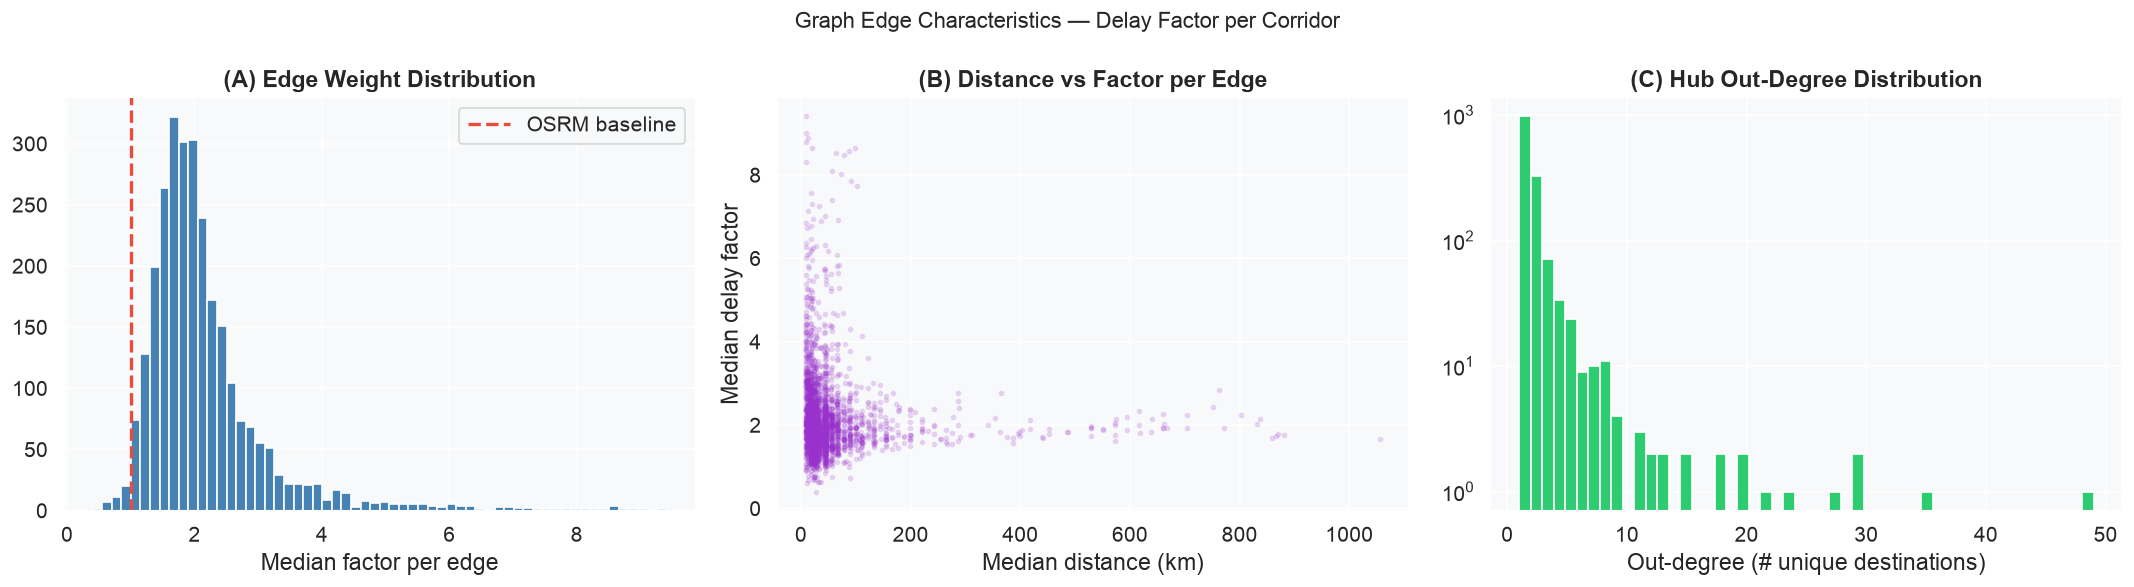


=== Top 10 Highest-Congestion Source Hubs ===
               count  median_factor  mean_factor
source_center                                   
IND847226AAA      64       8.582010     6.673830
IND847404AAB      36       7.859740     6.954117
IND401602AAA      24       7.307693     6.967440
IND829121AAA      50       7.061730     6.330934
IND175015AAA      41       6.924242     5.790445
IND302020AAA      25       6.272727     5.269717
IND821109AAA      24       5.753788     5.682915
IND700065AAB      29       5.468750     5.647756
IND181201AAB      24       5.240385     5.668953
IND147105AAA      21       4.666667     5.137251


In [10]:
# ============================================================
# CELL 8 — GRAPH STRUCTURE PREVIEW
# ============================================================

# ── Node inventory ───────────────────────────────────────────
all_hubs = pd.concat([
    df_clean["source_center"].rename("hub"),
    df_clean["destination_center"].rename("hub"),
]).drop_duplicates()

n_nodes = all_hubs.nunique()
print(f"🔵 Unique hub nodes : {n_nodes:,}")

# ── Edge inventory ───────────────────────────────────────────
edge_df = (
    df_clean
    .groupby(["source_center", "destination_center", "route_type"], observed=True)
    .agg(
        trips          = ("trip_uuid",       "nunique"),
        median_factor  = ("factor",          "median"),
        mean_factor    = ("factor",          "mean"),
        std_factor     = ("factor",          "std"),
        median_dist_km = ("actual_distance_to_destination", "median"),
    )
    .reset_index()
)

n_edges = len(edge_df)
print(f"🟢 Unique directed edges (src→dst×route_type): {n_edges:,}")
print(f"   of which FTL    : {(edge_df.route_type=='FTL').sum():,}")
print(f"   of which Carting: {(edge_df.route_type=='Carting').sum():,}")

# ── Top corridors by trip volume ─────────────────────────────
print("\n=== Top 10 Corridors by Trip Volume ===")
top_corridors = (
    edge_df.sort_values("trips", ascending=False).head(10)
    [["source_center","destination_center","route_type","trips","median_factor","median_dist_km"]]
)
print(top_corridors.to_string(index=False))

# ── Factor distribution on edges ────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Graph Edge Characteristics — Delay Factor per Corridor", fontsize=13)

ax = axes[0]
edge_df["median_factor"].hist(bins=60, ax=ax, color="steelblue", edgecolor="white")
ax.axvline(1.0, color=ACCENT, linewidth=2, linestyle="--", label="OSRM baseline")
ax.set_xlabel("Median factor per edge")
ax.set_title("(A) Edge Weight Distribution")
ax.legend()

ax = axes[1]
ax.scatter(edge_df["median_dist_km"], edge_df["median_factor"],
           alpha=0.15, s=6, c="darkorchid")
ax.set_xlabel("Median distance (km)")
ax.set_ylabel("Median delay factor")
ax.set_title("(B) Distance vs Factor per Edge")

ax = axes[2]
node_degree_out = df_clean.groupby("source_center")["destination_center"].nunique()
node_degree_out.hist(bins=50, ax=ax, color=OK, edgecolor="white")
ax.set_yscale("log")
ax.set_xlabel("Out-degree (# unique destinations)")
ax.set_title("(C) Hub Out-Degree Distribution")

plt.tight_layout()
plt.savefig("../data/graph_structure_preview.png", bbox_inches="tight")
plt.show()

# ── Hub congestion ranking ───────────────────────────────────
print("\n=== Top 10 Highest-Congestion Source Hubs ===")
hub_congestion = (
    df_clean.groupby("source_center", observed=True)["factor"]
    .agg(count="count", median_factor="median", mean_factor="mean")
    .query("count >= 20")
    .sort_values("median_factor", ascending=False)
    .head(10)
)
print(hub_congestion.to_string())


---
## 8 · Cutoff Analysis

`is_cutoff` flags trips where the parcel was held at a hub past its scheduled departure window. This represents **hub-level congestion / processing overload** — exactly the node feature our GraphSAGE model needs.


Global cutoff rate: 83.5%  (118,427 / 141,865 segments)

Factor statistics by is_cutoff:
              count   mean    std    min    25%    50%    75%    95%   max
is_cutoff                                                                 
False       23438.0  2.320  1.208  0.388  1.652  2.000  2.551  4.615  10.0
True       118427.0  1.977  0.768  0.203  1.596  1.833  2.143  3.222  10.0


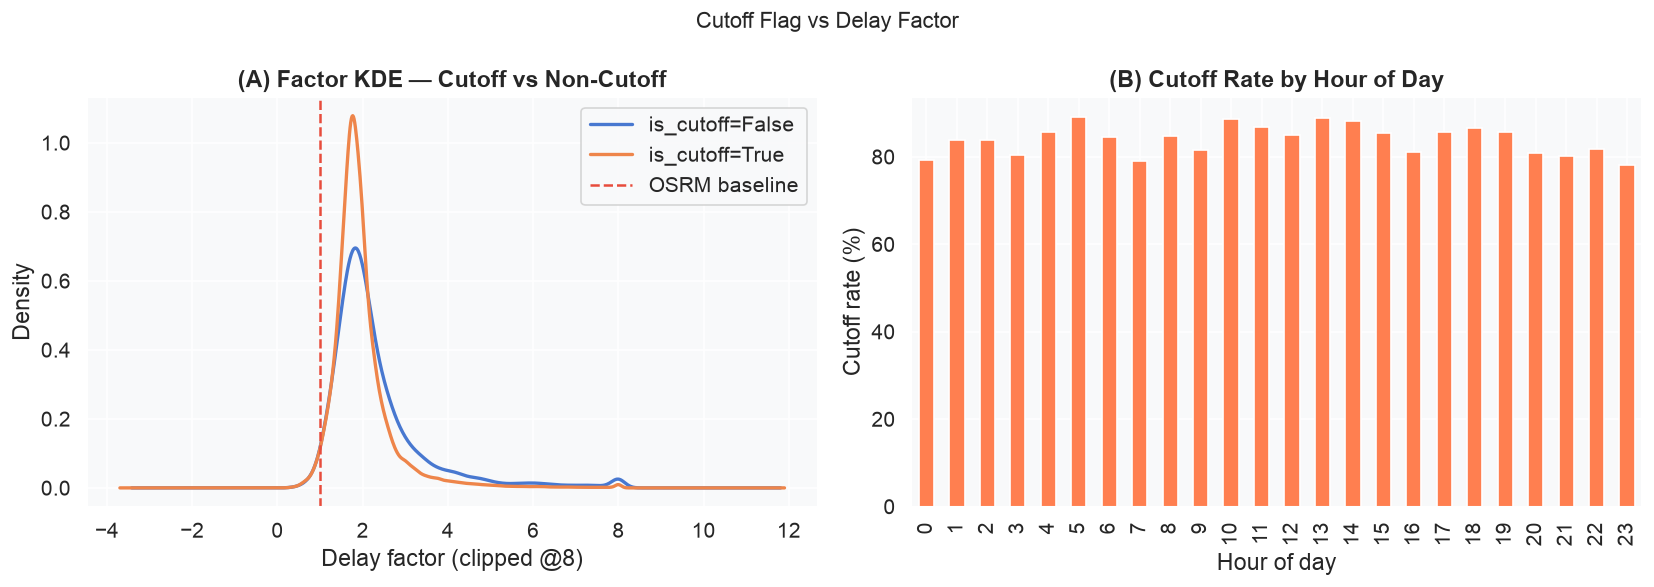

In [11]:
# ============================================================
# CELL 9 — CUTOFF ANALYSIS
# ============================================================

cutoff_rate = df_clean["is_cutoff"].mean()
print(f"Global cutoff rate: {cutoff_rate*100:.1f}%  ({df_clean['is_cutoff'].sum():,} / {len(df_clean):,} segments)")

# ── Factor by cutoff status ──────────────────────────────────
cutoff_factor = df_clean.groupby("is_cutoff")["factor"].describe(
    percentiles=[0.25, 0.5, 0.75, 0.95]
)
print("\nFactor statistics by is_cutoff:")
print(cutoff_factor.round(3).to_string())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Cutoff Flag vs Delay Factor", fontsize=13)

ax = axes[0]
for flag, grp in df_clean.groupby("is_cutoff"):
    grp["factor"].clip(0, 8).plot.kde(ax=ax, linewidth=2,
                                       label=f"is_cutoff={flag}")
ax.axvline(1.0, color=ACCENT, linestyle="--", linewidth=1.5, label="OSRM baseline")
ax.set_xlabel("Delay factor (clipped @8)")
ax.set_title("(A) Factor KDE — Cutoff vs Non-Cutoff")
ax.legend()

ax = axes[1]
# Cutoff rate per hour
co_hour = df_clean.groupby("hour_of_day")["is_cutoff"].mean() * 100
co_hour.plot(kind="bar", ax=ax, color="coral", edgecolor="white")
ax.set_xlabel("Hour of day")
ax.set_ylabel("Cutoff rate (%)")
ax.set_title("(B) Cutoff Rate by Hour of Day")

plt.tight_layout()
plt.savefig("../data/cutoff_analysis.png", bbox_inches="tight")
plt.show()


---
## 9 · Export Cleaned Data & EDA Summary

The cleaned DataFrame and a statistical summary JSON are saved to `../data/` for consumption by `02_data_pipeline.ipynb`.


In [12]:
# ============================================================
# CELL 10 — EXPORT CLEANED DATA & EDA SUMMARY
# ============================================================

import os, json
from datetime import datetime

os.makedirs("../data", exist_ok=True)

# ── Save cleaned parquet ─────────────────────────────────────
CLEAN_PATH = "../data/trips_clean.parquet"
df_clean.to_parquet(CLEAN_PATH, index=False)
print(f"✅ Cleaned data saved → {CLEAN_PATH}")
print(f"   Shape  : {df_clean.shape}")
print(f"   Size   : {os.path.getsize(CLEAN_PATH)/1e6:.1f} MB")

# ── Save EDA summary JSON (for automated tracking) ───────────
eda_summary = {
    "generated_at"              : datetime.utcnow().isoformat(),
    "raw_rows"                  : int(len(df_no_crit_nulls)),
    "clean_rows"                : int(len(df_clean)),
    "drop_pct"                  : float(round(drop_pct, 3)),
    "n_unique_hubs"             : int(n_nodes),
    "n_unique_edges"            : int(n_edges),
    "osrm_baseline_mae_min"     : float(round(mae_clean, 3)),
    "global_cutoff_rate_pct"    : float(round(cutoff_rate * 100, 2)),
    "median_delay_factor"       : float(round(df_clean["factor"].median(), 4)),
    "mean_delay_factor"         : float(round(df_clean["factor"].mean(), 4)),
    "pct_within_15pct_osrm"    : float(round(pct_within_15, 2)),
    "route_type_counts"         : df_clean["route_type"].value_counts().to_dict(),
}

SUMMARY_PATH = "../data/eda_summary.json"
with open(SUMMARY_PATH, "w") as f:
    json.dump(eda_summary, f, indent=2)

print(f"\n✅ EDA summary saved → {SUMMARY_PATH}")
print(json.dumps(eda_summary, indent=2))

# ── Final banner ─────────────────────────────────────────────
print("\n" + "="*60)
print("  EDA COMPLETE — KEY FINDINGS FOR GraphSAGE DESIGN")
print("="*60)
print(f"  OSRM underestimates by {(eda_summary['mean_delay_factor']-1)*100:.0f}% on average")
print(f"  Only {eda_summary['pct_within_15pct_osrm']:.0f}% of trips are within ±15% — business target to beat")
print(f"  Graph will have {n_nodes:,} node features and {n_edges:,} directed edges")
print(f"  Cutoffs affect {cutoff_rate*100:.0f}% of segments → critical node feature")
print("="*60)
print("\n→ Proceed to 02_data_pipeline.ipynb for graph construction")


✅ Cleaned data saved → ../data/trips_clean.parquet
   Shape  : (141865, 28)
   Size   : 7.3 MB

✅ EDA summary saved → ../data/eda_summary.json
{
  "generated_at": "2026-06-16T22:36:31.660817",
  "raw_rows": 144867,
  "clean_rows": 141865,
  "drop_pct": 2.072,
  "n_unique_hubs": 1655,
  "n_unique_edges": 2790,
  "osrm_baseline_mae_min": 203.656005859375,
  "global_cutoff_rate_pct": 83.48,
  "median_delay_factor": 1.8525999784469604,
  "mean_delay_factor": 2.033900022506714,
  "pct_within_15pct_osrm": 3.42,
  "route_type_counts": {
    "FTL": 98631,
    "Carting": 43234
  }
}

  EDA COMPLETE — KEY FINDINGS FOR GraphSAGE DESIGN
  OSRM underestimates by 103% on average
  Only 3% of trips are within ±15% — business target to beat
  Graph will have 1,655 node features and 2,790 directed edges
  Cutoffs affect 83% of segments → critical node feature

→ Proceed to 02_data_pipeline.ipynb for graph construction
